# Budget 2026 — Analyse & Anbefaling

Sammenligning af budget med reviderede tal, trendprojektion og foreslået justeret budget.

**Metode:** 5-års trend på reviderede tal (2021–2025), konservativ afrunding.  
**Mål:** Driftsresultat med 250.000 kr. overskud + buffer til henlæggelse.  
**Vedligeholdelse (genopretning):** Sat til 0 som standard.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ─── Styling ───
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Helvetica', 'Arial'],
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': '#c8c6c0',
    'axes.linewidth': 0.6,
    'grid.color': '#e8e6e1',
    'grid.linewidth': 0.5,
    'grid.alpha': 0.8,
    'figure.facecolor': '#faf9f7',
    'axes.facecolor': '#fcfcfb',
    'figure.dpi': 130,
})

# Colors (matching the artifact palette)
C_BUDGET = '#2a78d6'
C_ACTUAL = '#1baf7a'
C_SUGGESTED = '#eb6834'
C_HIGHLIGHT = '#eda100'
C_TEXT = '#1a1917'
C_TEXT_SEC = '#5c5a54'
C_TEXT_MUTED = '#8a8880'

# ─── Data ───
years = [2021, 2022, 2023, 2024, 2025]

budget_data = {
    'Indtægter':               {'budget': 4_685_000, 'rev_2025': 4_534_400, 'avg5': 4_067_340, 'suggested': 4_685_000},
    'Personaleomk.':           {'budget':   455_000, 'rev_2025':   471_040, 'avg5':   388_300, 'suggested':   475_000},
    'Forsikringer':            {'budget':   290_000, 'rev_2025':   300_947, 'avg5':   261_526, 'suggested':   320_000},
    'Afgifter':                {'budget':   765_000, 'rev_2025':   726_158, 'avg5':   679_459, 'suggested':   765_000},
    'Renholdelse':             {'budget':    45_000, 'rev_2025':    28_874, 'avg5':    38_681, 'suggested':    45_000},
    'Vedl. (løbende)':         {'budget':   700_000, 'rev_2025':   332_294, 'avg5':   380_005, 'suggested':   450_000},
    'Vedl. (genop.)':          {'budget':         0, 'rev_2025':   616_029, 'avg5': 1_659_527, 'suggested':         0},
    'Administration':          {'budget':   445_500, 'rev_2025':   522_332, 'avg5':   470_028, 'suggested':   530_000},
    'Afskrivninger':           {'budget':         0, 'rev_2025':         0, 'avg5':    22_195, 'suggested':         0},
    'Finansielle omk.':        {'budget':   448_000, 'rev_2025':   447_434, 'avg5':   542_316, 'suggested':   450_000},
}

# Revideret actuals per year (2021-2025)
actuals_by_year = {
    'Indtægter':       [3_686_252, 3_928_465, 3_893_373, 4_294_208, 4_534_400],
    'Personaleomk.':   [  366_487,   365_935,   368_075,   369_962,   471_040],
    'Forsikringer':    [  232_209,   240_215,   254_067,   280_193,   300_947],
    'Afgifter':        [  611_950,   642_810,   695_638,   720_737,   726_158],
    'Renholdelse':     [   45_297,    32_769,    38_436,    48_027,    28_874],
    'Vedl. (løbende)': [  300_437,   343_002,   487_975,   436_319,   332_294],
    'Vedl. (genop.)':  [4_370_038,   948_764, 1_173_495, 1_189_310,   616_029],
    'Administration':  [  402_799,   438_464,   467_610,   518_936,   522_332],
    'Afskrivninger':   [   63_175,    43_258,     4_542,         0,         0],
    'Finansielle omk.':[  776_554,   553_679,   473_974,   459_941,   447_434],
}

# Budget per year (2021-2025)
budget_by_year = {
    'Vedl. (løbende)': [700_000, 700_000, 700_000, 700_000, 700_000],
}

print("Data loaded ✓")

Data loaded ✓


## 1. Budget 2026 vs. Revideret 2025 vs. Foreslået — Nøgleposter

De fire poster med størst afvigelse mellem budget og faktisk forbrug.

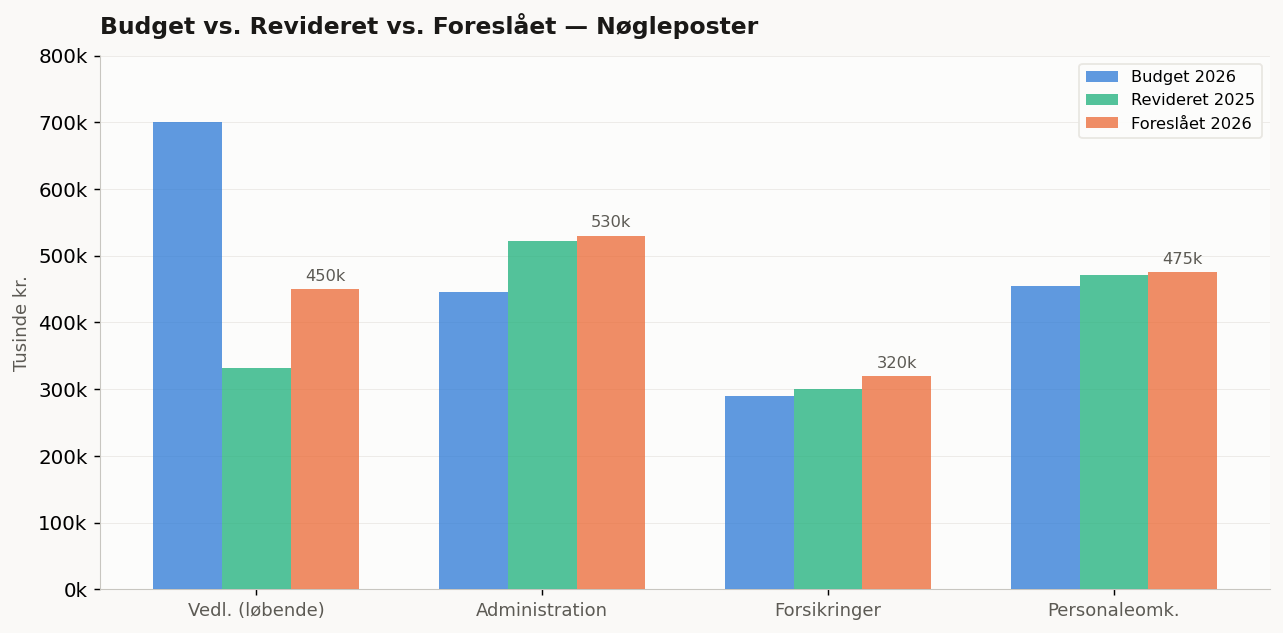

In [1]:
# ─── Fig 1: Grouped bar chart — key expense lines ───
key_lines = ['Vedl. (løbende)', 'Administration', 'Forsikringer', 'Personaleomk.']
labels = key_lines
budget_vals  = [budget_data[k]['budget']    / 1000 for k in key_lines]
actual_vals  = [budget_data[k]['rev_2025']  / 1000 for k in key_lines]
suggest_vals = [budget_data[k]['suggested'] / 1000 for k in key_lines]

x = np.arange(len(labels))
w = 0.24

fig, ax = plt.subplots(figsize=(10, 5))

bars1 = ax.bar(x - w, budget_vals,  w, label='Budget 2026',   color=C_BUDGET,    alpha=0.75, zorder=3)
bars2 = ax.bar(x,     actual_vals,  w, label='Revideret 2025', color=C_ACTUAL,    alpha=0.75, zorder=3)
bars3 = ax.bar(x + w, suggest_vals, w, label='Foreslået 2026', color=C_SUGGESTED, alpha=0.75, zorder=3)

# Round the data-end of bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        bar.set_linewidth(0)

# Direct labels on suggested bars
for i, v in enumerate(suggest_vals):
    ax.text(x[i] + w, v + 8, f'{v:.0f}k', ha='center', va='bottom',
            fontsize=9, color=C_TEXT_SEC, fontweight='500')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10, color=C_TEXT_SEC)
ax.set_ylabel('Tusinde kr.', fontsize=10, color=C_TEXT_SEC)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}k'))
ax.set_ylim(0, 800)
ax.grid(axis='y', zorder=0)
ax.legend(loc='upper right', frameon=True, facecolor='#fcfcfb', edgecolor='#e8e6e1',
          fontsize=9, framealpha=0.95)

ax.set_title('Budget vs. Revideret vs. Foreslået — Nøgleposter',
             fontsize=13, fontweight='bold', color=C_TEXT, pad=12, loc='left')

fig.tight_layout()
plt.show()

## 2. Vedligeholdelse (løbende) — Budget vs. revideret 2021–2025

Faktisk forbrug har ligget markant under budget hvert eneste år. Den største besparelse i det foreslåede budget.

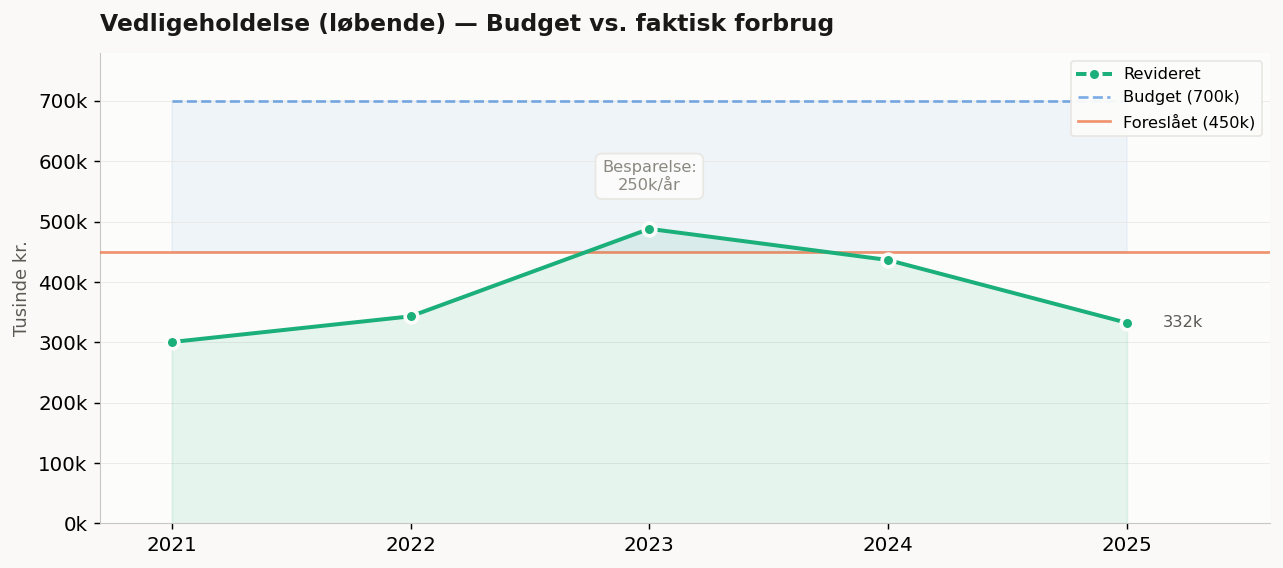

In [1]:
# ─── Fig 2: Vedligeholdelse (løbende) — line + area ───
vedl_actual = np.array(actuals_by_year['Vedl. (løbende)']) / 1000
vedl_budget = np.array(budget_by_year['Vedl. (løbende)']) / 1000
suggested_level = 450

fig, ax = plt.subplots(figsize=(10, 4.5))

# Area fill under actuals
ax.fill_between(years, vedl_actual, alpha=0.10, color=C_ACTUAL, zorder=2)

# Lines
ax.plot(years, vedl_actual, color=C_ACTUAL, linewidth=2.2, marker='o', markersize=7,
        markerfacecolor=C_ACTUAL, markeredgecolor='#fcfcfb', markeredgewidth=2,
        label='Revideret', zorder=4)
ax.plot(years, vedl_budget, color=C_BUDGET, linewidth=1.5, linestyle='--', alpha=0.6,
        label='Budget (700k)', zorder=3)

# Suggested level
ax.axhline(y=suggested_level, color=C_SUGGESTED, linewidth=1.5, linestyle='-', alpha=0.7,
           label='Foreslået (450k)', zorder=3)

# Shade the saving between budget and suggested
ax.fill_between(years, suggested_level, vedl_budget[:len(years)],
                alpha=0.06, color=C_BUDGET, zorder=1)
mid_y = (700 + 450) / 2
ax.annotate('Besparelse:\n250k/år', xy=(2023, mid_y), fontsize=9,
            color=C_TEXT_MUTED, ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#fcfcfb', edgecolor='#e8e6e1', alpha=0.9))

# End-dot label
ax.text(2025.15, vedl_actual[-1], f'{vedl_actual[-1]:.0f}k', fontsize=9,
        color=C_TEXT_SEC, va='center')

ax.set_xlim(2020.7, 2025.6)
ax.set_ylim(0, 780)
ax.set_xticks(years)
ax.set_ylabel('Tusinde kr.', fontsize=10, color=C_TEXT_SEC)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}k'))
ax.grid(axis='y', zorder=0)
ax.legend(loc='upper right', frameon=True, facecolor='#fcfcfb', edgecolor='#e8e6e1',
          fontsize=9, framealpha=0.95)

ax.set_title('Vedligeholdelse (løbende) — Budget vs. faktisk forbrug',
             fontsize=13, fontweight='bold', color=C_TEXT, pad=12, loc='left')

fig.tight_layout()
plt.show()

## 3. Trend alle udgiftsposter — Revideret 2021–2025

Overblik over hvordan de individuelle udgiftsposter har udviklet sig over de seneste 5 år.

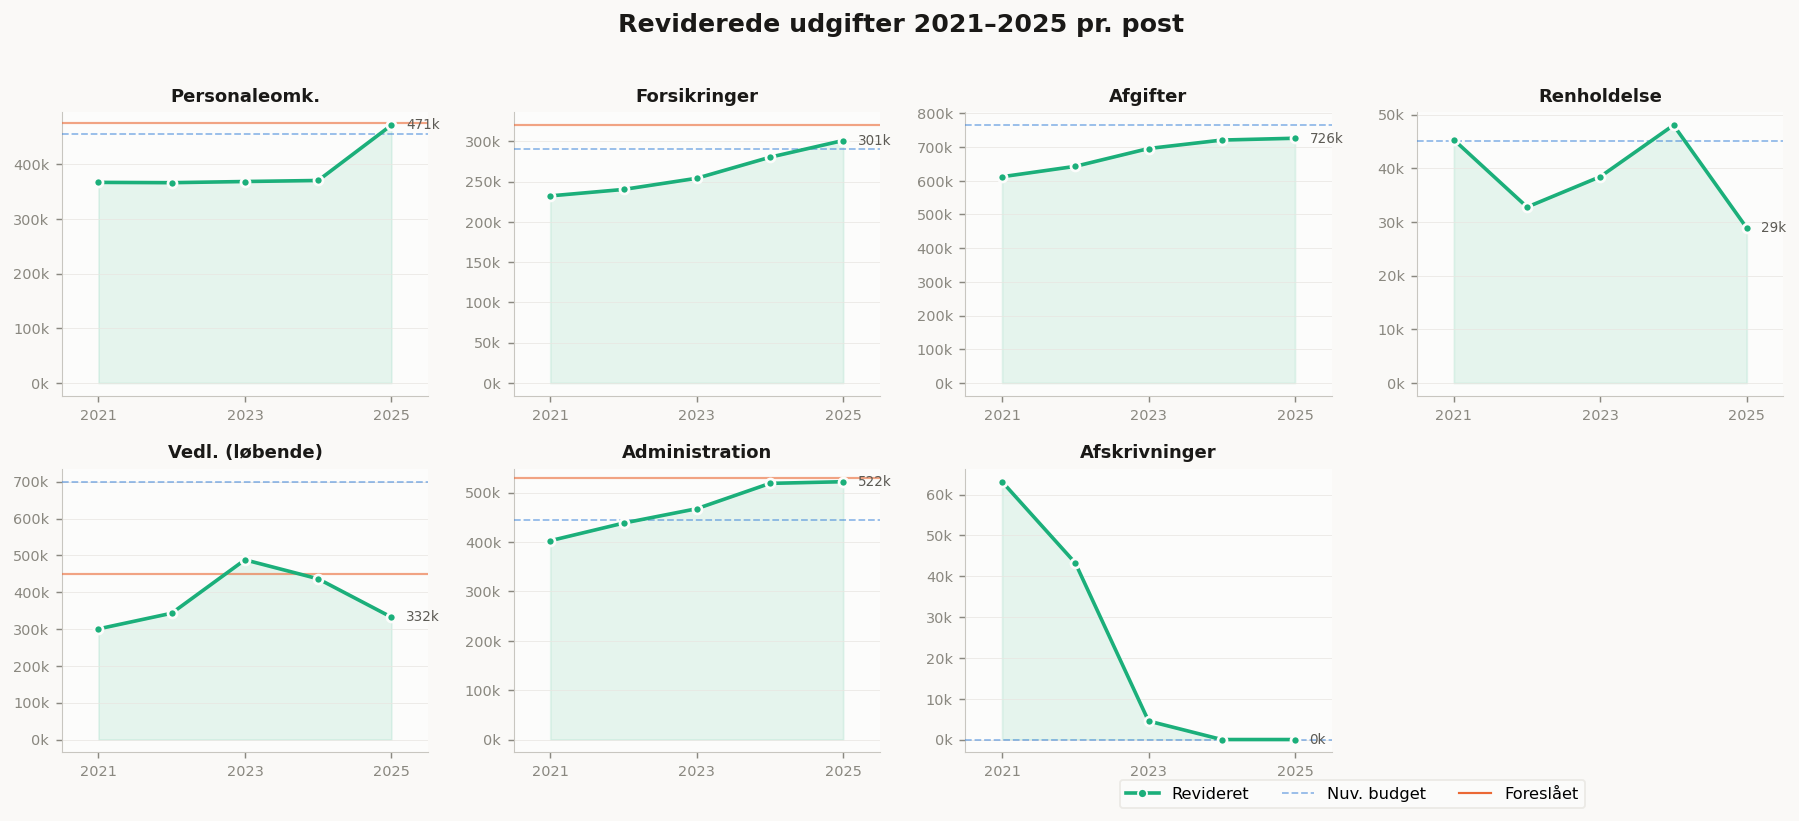

In [1]:
# ─── Fig 3: Small multiples — all expense lines 2021–2025 ───
expense_lines = [k for k in actuals_by_year if k != 'Indtægter' and k != 'Vedl. (genop.)']

fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharey=False)
axes = axes.flatten()

for i, name in enumerate(expense_lines):
    ax = axes[i]
    vals = np.array(actuals_by_year[name]) / 1000
    bud = budget_data[name]['budget'] / 1000
    sug = budget_data[name]['suggested'] / 1000
    
    # Area + line
    ax.fill_between(years, vals, alpha=0.10, color=C_ACTUAL)
    ax.plot(years, vals, color=C_ACTUAL, linewidth=2, marker='o', markersize=5,
            markerfacecolor=C_ACTUAL, markeredgecolor='#fcfcfb', markeredgewidth=1.5, zorder=4)
    
    # Budget line
    ax.axhline(y=bud, color=C_BUDGET, linewidth=1, linestyle='--', alpha=0.5, zorder=3)
    
    # Suggested line
    if sug != bud:
        ax.axhline(y=sug, color=C_SUGGESTED, linewidth=1.2, alpha=0.6, zorder=3)
    
    ax.set_title(name, fontsize=10, fontweight='600', color=C_TEXT, pad=6)
    ax.set_xticks([2021, 2023, 2025])
    ax.set_xlim(2020.5, 2025.5)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}k'))
    ax.tick_params(labelsize=8, colors=C_TEXT_MUTED)
    ax.grid(axis='y', zorder=0)
    
    # End label
    ax.text(2025.2, vals[-1], f'{vals[-1]:.0f}k', fontsize=7.5, color=C_TEXT_SEC, va='center')

# Hide unused subplot
axes[-1].set_visible(False)

fig.suptitle('Reviderede udgifter 2021–2025 pr. post', fontsize=14, fontweight='bold',
             color=C_TEXT, y=1.01)

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=C_ACTUAL, linewidth=2, marker='o', markersize=5,
           markerfacecolor=C_ACTUAL, markeredgecolor='#fcfcfb', label='Revideret'),
    Line2D([0], [0], color=C_BUDGET, linewidth=1, linestyle='--', alpha=0.5, label='Nuv. budget'),
    Line2D([0], [0], color=C_SUGGESTED, linewidth=1.2, label='Foreslået'),
]
fig.legend(handles=legend_elements, loc='lower right', bbox_to_anchor=(0.88, -0.02),
           ncol=3, fontsize=9, frameon=True, facecolor='#fcfcfb', edgecolor='#e8e6e1')

fig.tight_layout()
plt.show()

## 4. Disponering af driftsresultat

Visualisering af hvordan det foreslåede driftsresultat på 1.650.000 kr. fordeles.

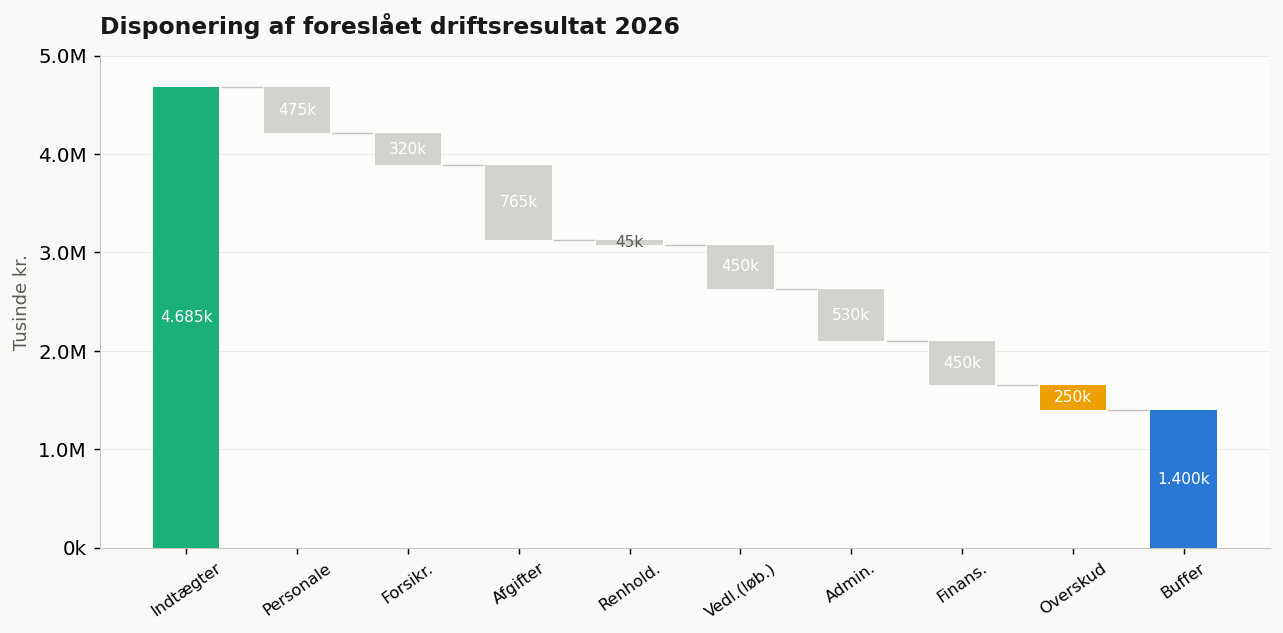

In [1]:
# ─── Fig 4: Waterfall — budget to surplus + buffer ───
fig, ax = plt.subplots(figsize=(10, 5))

categories = ['Indtægter', 'Personaleomk.', 'Forsikringer', 'Afgifter', 'Renholdelse',
              'Vedl. (løb.)', 'Administration', 'Finansielle', 'Overskud', 'Buffer']
values =     [4685, -475, -320, -765, -45, -450, -530, -450, -250, -1400]

# Compute cumulative for waterfall
cumulative = [0] * len(values)
cumulative[0] = values[0]
for i in range(1, len(values)):
    cumulative[i] = cumulative[i-1] + values[i]

# Bar bottoms
bottoms = [0] * len(values)
bottoms[0] = 0  # starts from 0
for i in range(1, len(values)):
    bottoms[i] = cumulative[i-1]

colors = []
for i, v in enumerate(values):
    if i == 0:
        colors.append(C_ACTUAL)       # Revenue — green
    elif categories[i] == 'Overskud':
        colors.append(C_HIGHLIGHT)     # Target surplus
    elif categories[i] == 'Buffer':
        colors.append(C_BUDGET)        # Buffer — blue
    else:
        colors.append('#d4d2cc')       # Expenses — neutral gray

bars = ax.bar(categories, [abs(v) for v in values], bottom=[b if v >= 0 else b + v for b, v in zip(bottoms, values)],
              color=colors, width=0.6, edgecolor='none', zorder=3)

# Value labels
for i, (bar, v) in enumerate(zip(bars, values)):
    y_pos = bar.get_y() + bar.get_height() / 2
    label = f'{abs(v):,}k'.replace(',', '.')
    ax.text(bar.get_x() + bar.get_width() / 2, y_pos, label,
            ha='center', va='center', fontsize=8.5, color='white' if abs(v) > 200 else C_TEXT_SEC,
            fontweight='500')

# Connector lines
for i in range(len(values) - 1):
    y = cumulative[i]
    ax.plot([i + 0.32, i + 0.68], [y, y], color='#c8c6c0', linewidth=0.8, zorder=2)

ax.set_ylabel('Tusinde kr.', fontsize=10, color=C_TEXT_SEC)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1000:.1f}M' if v >= 1000 else f'{v:.0f}k'))
ax.set_ylim(0, 5000)
ax.grid(axis='y', zorder=0)
ax.tick_params(axis='x', rotation=35, labelsize=9)

ax.set_title('Disponering af foreslået driftsresultat 2026',
             fontsize=13, fontweight='bold', color=C_TEXT, pad=12, loc='left')
ax.set_xlabel('')

fig.tight_layout()
plt.show()

## 5. Opsummering

| | Nuværende | Foreslået | Ændring |
|---|---:|---:|---:|
| **Indtægter** | 4.685.000 | 4.685.000 | — |
| **Sum udgifter** | 3.148.500 | 3.035.000 | −113.500 |
| **Driftsresultat** | 1.536.500 | 1.650.000 | +113.500 |
| Heraf: Målsat overskud | | **250.000** | |
| Heraf: Buffer / henlæggelse | | **1.400.000** | |

**Vigtigste justeringer:**
- Vedligeholdelse (løbende): 700k → 450k (−250k) — aktuelle udgifter markant lavere
- Administration: 446k → 530k (+85k) — stigende trend ikke dækket
- Forsikringer: 290k → 320k (+30k) — 2025-tal overstiger budget
- Personale: 455k → 475k (+20k) — 2025-hop til nyt niveau

Bufferen på 1.400.000 kan disponeres til genopretning/renovering eller reserveopbygning.